# killer 무더기 = 포화 — 성공 키워드를 쌓아도 시너지는 안 좋아진다

> 모델 v2_sweepA · 확정 killer 89 / 매개 79 · 가상노드 재추론(`score_concept_batch`)
> finding: [`2026-06-23_killer-스태킹-포화`](../../docs/findings/2026-06-23_killer-스태킹-포화.md)

## 질문
성공을 담보하는 killer 키워드를 **무더기로 합치면 그만큼 더 좋아지나?**

## TL;DR — 아니다. 핵심은 '시너지 상승'이 아니라 '희석 회피'
1. **A 누적 스택**: 첫 killer가 성공확률을 천장(~0.65)으로. 2번째부터 한계기여 ~0 (포화).
2. **B 헤드룸**: 같은 killer를 빈 베이스에 = +0.54 / killer 든 베이스에 = ~0. 헤드룸은 베이스 속성.
3. **C synergy ⟂ 단독강도**: corr ~ −1.0. 시너지는 합산이 아니라 약한 베이스 salvage.
4. **③ killer에 뭘 붙이나**: +killer ≈ +매개 (~0, 포화) **≫ +일반 (−0.32)**. killer끼리 특별 시너지 없음. 일반어 희석은 손해.
5. **④ 채움 궤적**: 강한 killer + **매개로 채우면 ~0.70 유지**, **일반으로 채우면 0.65→0.10 붕괴**.
6. **⑤ 쌍 시너지 vs 성공 (역설)**: 비-killer(일반×일반) 쌍이 **시너지는 최고**(−0.07)지만 **성공확률은 최저**(0.07). → 시너지≠성공.
7. **⑥ 실제 사례**: 빼빼로·박카스·메론킥 등 성공작 = 강한 killer + 매개, 군더더기 적음. 실패작 = killer 있어도 일반어 12~14개로 희석.

In [1]:
# ── Setup ──
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.exists(os.path.join(_root, 'src', 'eval', 'md', 'engine.py')):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
for _f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic']:
    try:
        matplotlib.rc('font', family=_f); break
    except Exception:
        pass
matplotlib.rcParams['axes.unicode_minus'] = False

from src.eval.md.engine import MDEngine, EngineConfig
eng = MDEngine(EngineConfig.v2_sweepA()).run_single_inference()
kf = pd.read_csv('data/processed/hin/keyword_final.csv')

def _ids(mask):
    r = [eng.seed_to_idx(k) for k in kf[mask].keyword]
    return [i for i in r if i is not None]

K = _ids(kf.tag == 'killer'); M = _ids(kf.tag == '매개')
N = _ids((kf.tag == 'neutral') & (kf['빈도'] >= 10))   # 실제 속성인 일반 키워드
rng = np.random.default_rng(0)
s0 = eng.score_concept([])
single = eng.score_concept_batch([[i] for i in K]) - s0   # killer 단독강도
print(f'killer {len(K)} · 매개 {len(M)} · 일반 {len(N)} · s0={s0:.3f} · killer 단독lift 평균 {single.mean():+.3f}')

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


killer 89 · 매개 79 · 일반 320 · s0=0.041 · killer 단독lift 평균 +0.551


## A. killer n개 누적 스택 — 첫 개가 거의 전부
killer를 무작위로 1→14개 쌓을 때 평균 성공확률. 한계기여(n번째 Δ)가 0으로 감쇠하면 포화.

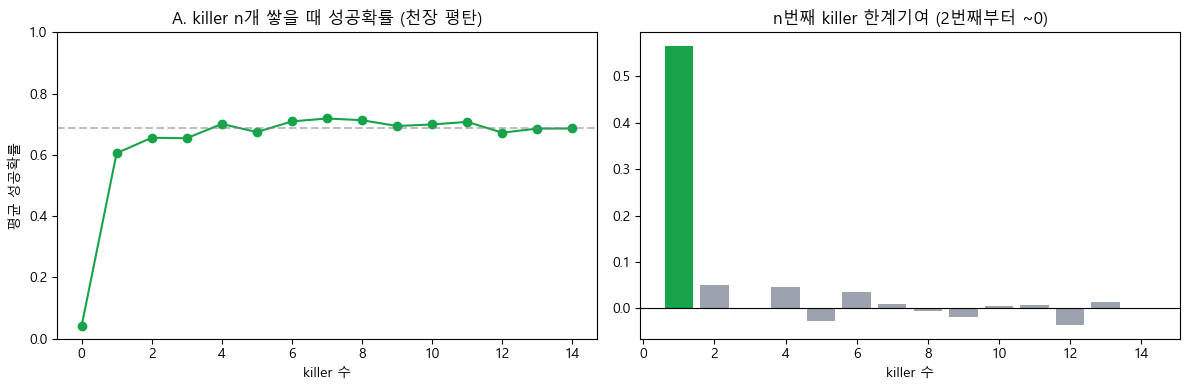

첫 killer Δ=+0.565 · 이후 평균 Δ=+0.0062


In [2]:
NMAX, R = 14, 40
ns = list(range(1, NMAX + 1))
probs = [float(eng.score_concept_batch([list(rng.choice(K, n, replace=False)) for _ in range(R)]).mean()) for n in ns]
marg = [probs[0] - s0] + [probs[i] - probs[i-1] for i in range(1, len(probs))]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([0]+ns, [s0]+probs, 'o-', color='#16A34A'); ax[0].axhline(probs[-1], ls='--', c='gray', alpha=.5)
ax[0].set_title('A. killer n개 쌓을 때 성공확률 (천장 평탄)'); ax[0].set_xlabel('killer 수'); ax[0].set_ylabel('평균 성공확률'); ax[0].set_ylim(0, 1)
ax[1].bar(ns, marg, color=['#16A34A']+['#9CA3AF']*(len(ns)-1)); ax[1].axhline(0, c='k', lw=.8)
ax[1].set_title('n번째 killer 한계기여 (2번째부터 ~0)'); ax[1].set_xlabel('killer 수')
plt.tight_layout(); plt.show()
print('첫 killer Δ=%+.3f · 이후 평균 Δ=%+.4f' % (marg[0], np.mean(marg[1:])))
print('\n[스택 수별 상세 성공확률 및 한계기여]')
print('m=0 (베이스) | 성공확률: %.3f | 한계기여: -' % s0)
for n, p, m in zip(ns, probs, marg):
    print('m=%-2d         | 성공확률: %.3f | 한계기여: %+.3f' % (n, p, m))


## B. 헤드룸 대조 — 같은 killer, 베이스 강도별 한계기여
베이스에 killer가 m개 있을 때 새 killer 추가 Δ. 베이스가 비면 +0.5, 차면 ~0 → 헤드룸은 베이스 속성.

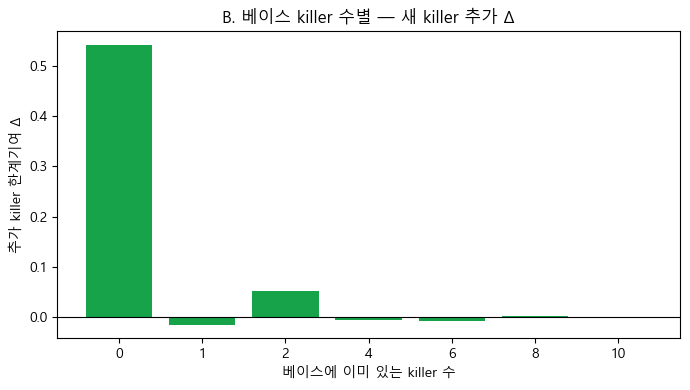

빈 베이스 +0.541 → killer 1개 베이스 -0.0151


In [3]:
ms = [0, 1, 2, 4, 6, 8, 10]; addD = []
for m in ms:
    ds = []
    for _ in range(10):
        base = list(rng.choice(K, m, replace=False)) if m else []
        bs = eng.score_concept(base); bset = set(base)
        cand = rng.choice([i for i in K if i not in bset], 20, replace=False)
        ds.append(float((eng.score_concept_batch([base + [int(a)] for a in cand]) - bs).mean()))
    addD.append(np.mean(ds))
plt.figure(figsize=(7, 4)); plt.bar([str(m) for m in ms], addD, color='#16A34A'); plt.axhline(0, c='k', lw=.8)
plt.title('B. 베이스 killer 수별 — 새 killer 추가 Δ'); plt.xlabel('베이스에 이미 있는 killer 수'); plt.ylabel('추가 killer 한계기여 Δ')
plt.tight_layout(); plt.show()
print('빈 베이스 +%.3f → killer 1개 베이스 %+.4f' % (addD[0], addD[1]))

## C. synergy ⟂ 단독강도 — 강한 killer일수록 더할 여지 없음
synergy = margin(k | 강한 더미) − margin(k | 단독). 단독강도 클수록 synergy 음(=합산 아닌 salvage).

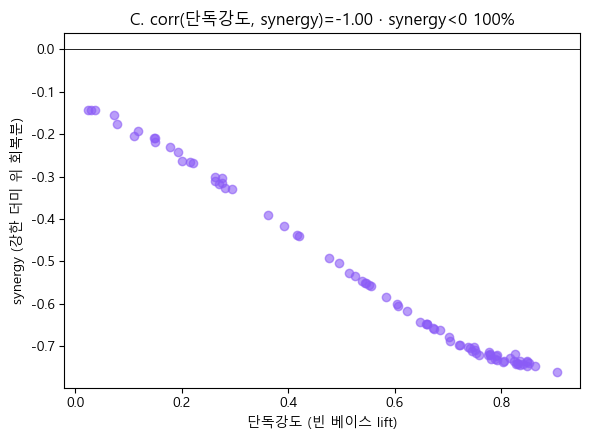

mean synergy=-0.549 → 강한 것끼리 합산 아니라 약한 걸 살리는 salvage


In [4]:
base = list(rng.choice(K, 6, replace=False)); bs = eng.score_concept(base)
held = [i for i in K if i not in set(base)]
single_h = eng.score_concept_batch([[i] for i in held]) - s0
syn = (eng.score_concept_batch([base + [int(i)] for i in held]) - bs) - single_h
r = np.corrcoef(single_h, syn)[0, 1]
plt.figure(figsize=(6, 4.5)); plt.scatter(single_h, syn, c='#8B5CF6', alpha=.6); plt.axhline(0, c='k', lw=.6)
plt.xlabel('단독강도 (빈 베이스 lift)'); plt.ylabel('synergy (강한 더미 위 회복분)')
plt.title(f'C. corr(단독강도, synergy)={r:.2f} · synergy<0 {100*(syn<0).mean():.0f}%')
plt.tight_layout(); plt.show()
print('mean synergy=%+.3f → 강한 것끼리 합산 아니라 약한 걸 살리는 salvage' % syn.mean())

## ③ killer에 무엇을 붙이나 — killer vs 매개 vs 일반 (핵심 대조)
base=killer 1개(prob~0.6) 고정 후 다음 키워드 타입만 바꿔 한계기여 비교. killer끼리 특별 시너지가 있나, 아니면 매개·일반과 같나.

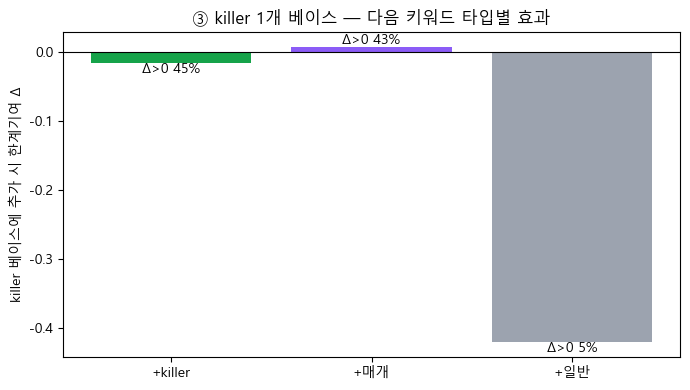

+killer 평균 -0.017 · 중앙 -0.012 · Δ>0 45%
+매개 평균 +0.007 · 중앙 -0.017 · Δ>0 43%
+일반 평균 -0.421 · 중앙 -0.431 · Δ>0 5%


In [5]:
res = {'+killer': [], '+매개': [], '+일반': []}
for _ in range(15):
    base = [int(rng.choice(K))]; bs = eng.score_concept(base); bset = set(base)
    for lbl, grp in [('+killer', [i for i in K if i not in bset]), ('+매개', M), ('+일반', N)]:
        arr = rng.choice(grp, 20, replace=False)
        res[lbl].extend((eng.score_concept_batch([base + [int(x)] for x in arr]) - bs).tolist())
labels = ['+killer', '+매개', '+일반']
means = [float(np.mean(res[l])) for l in labels]; posr = [100*float(np.mean(np.array(res[l]) > 0)) for l in labels]
plt.figure(figsize=(7, 4)); bars = plt.bar(labels, means, color=['#16A34A', '#8B5CF6', '#9CA3AF']); plt.axhline(0, c='k', lw=.8)
plt.ylabel('killer 베이스에 추가 시 한계기여 Δ'); plt.title('③ killer 1개 베이스 — 다음 키워드 타입별 효과')
for b, p in zip(bars, posr):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f'Δ>0 {p:.0f}%', ha='center', va='bottom' if b.get_height() >= 0 else 'top')
plt.tight_layout(); plt.show()
for l in labels:
    print('%s 평균 %+.3f · 중앙 %+.3f · Δ>0 %.0f%%' % (l, np.mean(res[l]), np.median(res[l]), 100*np.mean(np.array(res[l]) > 0)))

## ④ 채움 궤적 — 강한 killer 1개 + 매개 채움 vs 일반 채움
강한 killer 1개에서 시작해 매개 / 일반을 하나씩 5개까지 더할 때 성공확률 추이. 매개는 유지, 일반은 붕괴.

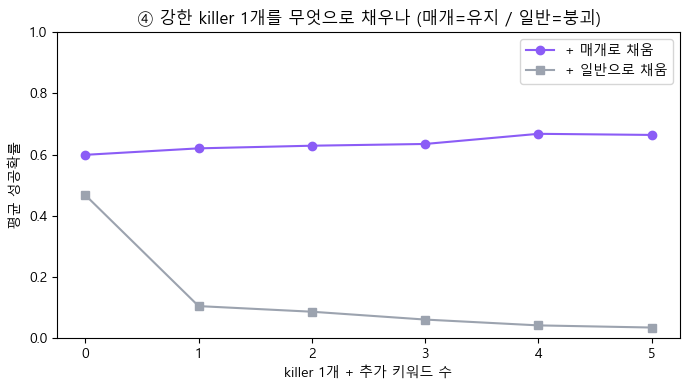

매개 채움: 0.60 0.62 0.63 0.63 0.67 0.66
일반 채움: 0.47 0.10 0.09 0.06 0.04 0.03 (희석으로 붕괴)


In [6]:
def traj(grp):
    out = []
    for _ in range(20):
        base = [int(rng.choice(K))]; add = list(rng.choice(grp, 5, replace=False)); cur = base[:]
        row = [eng.score_concept(cur)]
        for a in add:
            cur = cur + [int(a)]; row.append(eng.score_concept(cur))
        out.append(row)
    return np.array(out).mean(0)
tm, tn = traj(M), traj(N)
xs = list(range(0, 6))
plt.figure(figsize=(7, 4))
plt.plot(xs, tm, 'o-', color='#8B5CF6', label='+ 매개로 채움')
plt.plot(xs, tn, 's-', color='#9CA3AF', label='+ 일반으로 채움')
plt.ylim(0, 1); plt.xlabel('killer 1개 + 추가 키워드 수'); plt.ylabel('평균 성공확률'); plt.legend()
plt.title('④ 강한 killer 1개를 무엇으로 채우나 (매개=유지 / 일반=붕괴)')
plt.tight_layout(); plt.show()
print('매개 채움: %s' % ' '.join('%.2f' % v for v in tm))
print('일반 채움: %s (희석으로 붕괴)' % ' '.join('%.2f' % v for v in tn))

## ⑤ 쌍 시너지 vs 성공 — 비-killer 쌍이 시너지는 높지만 성공은 낮다 (역설)
2차 상호작용 synergy = s(ab)−s(a)−s(b)+s0. 비-killer(일반×일반)는 헤드룸이 커 시너지 최고지만, 조각이 약해 조합 성공확률은 최저.
→ **시너지가 높은 조합 ≠ 성공하는 조합.** 시너지는 salvage 신호이지 성공 신호가 아니다.

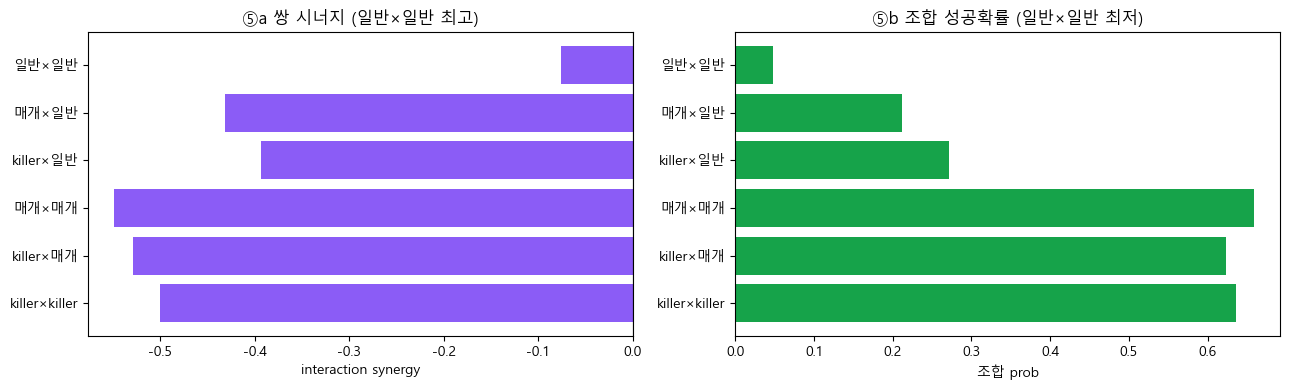

killer×killer  synergy -0.500 | 조합 prob 0.637
killer×매개      synergy -0.528 | 조합 prob 0.623
매개×매개          synergy -0.548 | 조합 prob 0.659
killer×일반      synergy -0.393 | 조합 prob 0.271
매개×일반          synergy -0.431 | 조합 prob 0.212
일반×일반          synergy -0.076 | 조합 prob 0.047


In [7]:
sAll = dict(zip(K, eng.score_concept_batch([[i] for i in K])))
sAll.update(dict(zip(M, eng.score_concept_batch([[i] for i in M]))))
sAll.update(dict(zip(N, eng.score_concept_batch([[i] for i in N]))))
def pair_stats(gA, gB, R=120):
    P = []
    for _ in range(R):
        a, b = int(rng.choice(gA)), int(rng.choice(gB))
        if a != b: P.append((a, b))
    sab = eng.score_concept_batch([[a, b] for a, b in P])
    I = np.array([sab[i] - sAll[a] - sAll[b] + s0 for i, (a, b) in enumerate(P)])
    return I.mean(), sab.mean()
combos = [('killer×killer', K, K), ('killer×매개', K, M), ('매개×매개', M, M),
          ('killer×일반', K, N), ('매개×일반', M, N), ('일반×일반', N, N)]
names, syns, probs2 = [], [], []
for nm, a, b in combos:
    I, p = pair_stats(a, b); names.append(nm); syns.append(I); probs2.append(p)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(names, syns, color='#8B5CF6'); ax[0].axvline(0, c='k', lw=.8); ax[0].set_title('⑤a 쌍 시너지 (일반×일반 최고)'); ax[0].set_xlabel('interaction synergy')
ax[1].barh(names, probs2, color='#16A34A'); ax[1].set_title('⑤b 조합 성공확률 (일반×일반 최저)'); ax[1].set_xlabel('조합 prob')
plt.tight_layout(); plt.show()
for nm, I, p in zip(names, syns, probs2):
    print('%-14s synergy %+.3f | 조합 prob %.3f' % (nm, I, p))

## ② 약한 killer vs 강한 killer 스태킹 — 어느 쪽도 이득 없음
단독강도 하위 30 vs 상위 30 killer만 스택. 강한 건 1개부터 천장, 약한 건 쌓아도 안 누적.

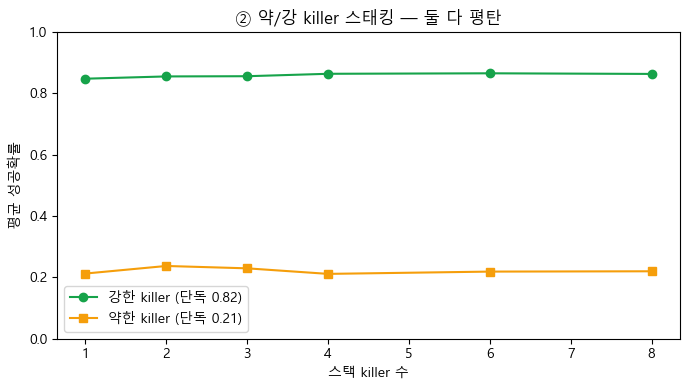

강한: 0.85 0.86 0.86 0.86 0.87 0.86
약한: 0.21 0.24 0.23 0.21 0.22 0.22 (안 누적)


In [8]:
order = np.argsort(single)
weak = [K[i] for i in order[:30]]; strong = [K[i] for i in order[-30:]]
ns2 = [1, 2, 3, 4, 6, 8]
def curve(grp):
    return [float(eng.score_concept_batch([list(rng.choice(grp, n, replace=False)) for _ in range(30)]).mean()) for n in ns2]
cw, cs = curve(weak), curve(strong)
plt.figure(figsize=(7, 4))
plt.plot(ns2, cs, 'o-', color='#16A34A', label=f'강한 killer (단독 {single[order[-30:]].mean():.2f})')
plt.plot(ns2, cw, 's-', color='#F59E0B', label=f'약한 killer (단독 {single[order[:30]].mean():.2f})')
plt.ylim(0, 1); plt.xlabel('스택 killer 수'); plt.ylabel('평균 성공확률'); plt.legend()
plt.title('② 약/강 killer 스태킹 — 둘 다 평탄'); plt.tight_layout(); plt.show()
print('강한: %s' % ' '.join('%.2f' % c for c in cs)); print('약한: %s (안 누적)' % ' '.join('%.2f' % c for c in cw))

## ⑥ 실제 제품 사례 — 이 방향으로 기획된 성공작 (model-free)
"강한 killer + 매개, 군더더기(일반) 적음" 레시피에 부합한 **성공 제품**과, "killer 있어도 일반어로 희석"한 **실패 제품** 대조. metric: 세븐=매출 / CU·GS25=좋아요.

In [9]:
def _nid(x):
    try: return str(int(float(x)))
    except Exception: return str(x)
tagm = dict(zip(kf.keyword, kf.tag))
pn = pd.read_parquet('data/processed/hin/product_nodes_final.parquet')
pos = pd.read_parquet('data/processed/pos_product_features.parquet')
ins = pd.read_parquet('data/processed/instagram_engagement_with_keywords.parquet')
metric = {}
psales = {_nid(r.ITEM_CD): float(r.sales_30d_amt) for r in pos.itertuples()}
for cd in pn[pn['편의점명'] == '세븐일레븐']['ITEM_CD']:
    v = psales.get(_nid(cd))
    if v and v > 0: metric[cd] = (v, '매출')
for (c, nm), v in ins[ins['편의점명'].isin(['CU', 'GS25'])].groupby(['편의점명', '정규화명'])['좋아요 수'].sum().items():
    metric.setdefault(f'{c}_{nm}', (float(v), '좋아요'))
def fmt(cd):
    v = metric.get(cd)
    if not v: return '—'
    a, u = v
    return ('%.1f억' % (a/1e8)) if u == '매출' and a >= 1e8 else ('%d만' % (a/1e4)) if u == '매출' else '%s♥' % format(int(a), ',')
rows = []
for r in pn.itertuples():
    kws = r.키워드_final
    if kws is None or len(kws) == 0: continue
    tags = [tagm.get(k, 'neutral') for k in kws]
    rows.append(dict(cd=r.ITEM_CD, nm=r.ITEM_NM, succ=(r.성공여부 == '성공'),
                     nk=tags.count('killer'), nmed=tags.count('매개'), nmine=tags.count('mine'), nneu=tags.count('neutral'),
                     tot=len(tags), ratio=(tags.count('killer')+tags.count('매개'))/len(tags),
                     kills=[k for k, t in zip(kws, tags) if t == 'killer'], meds=[k for k, t in zip(kws, tags) if t == '매개']))
df = pd.DataFrame(rows)
df['msort'] = df['cd'].map(lambda c: metric.get(c, (0, ''))[0])
good = df[(df.succ) & (df.nk >= 1) & (df.nmine == 0) & (df.ratio >= 0.5) & (df.tot <= 8)].sort_values('msort', ascending=False)
print('레시피 부합 성공제품 %d개 — 상위 10:' % len(good))
for _, r in good.head(10).iterrows():
    print('  %s (%s) | killer:%s · 매개:%s · 일반%d' % (r.nm, fmt(r.cd), '·'.join(r.kills), '·'.join(r.meds) or '-', r.nneu))
print()
bad = df[(~df.succ) & (df.nk >= 1) & (df.nneu >= 5)].sort_values('nneu', ascending=False)
print('대조 — killer 있는데 일반어로 희석한 실패제품:')
for _, r in bad.head(6).iterrows():
    print('  %s | killer:%s · 일반 %d개로 희석' % (r.nm, '·'.join(r.kills), r.nneu))

레시피 부합 성공제품 92개 — 상위 10:
  롯데)아몬드빼빼로37g(테디베어) (3942만) | killer:한정·빼빼로 · 매개:아몬드 · 일반3
  롯데)초코빼빼로54g(테디베어) (3288만) | killer:빼빼로·과자 · 매개:- · 일반2
  농심)메론킥60g (2566만) | killer:바삭·과자 · 매개:멜론·농심 · 일반2
  KBO)롯데자이언츠씨앗호떡빵97g (2085만) | killer:촉촉·시즌·한정·빵 · 매개:호떡 · 일반3
  동아)박카스F120ml10입(판매전용)  (2017만) | killer:박카스·타우린 · 매개:- · 일반2
  롯데)빼빼로말차37g(청수당) (1531만) | killer:빼빼로·과자·진함 · 매개:말차 · 일반3
  롯데)아몬드8갑(스키즈25년) (1405만) | killer:빼빼로·과자 · 매개:아몬드 · 일반1
  3테디베어)빼빼로4입기획 (1188만) | killer:빼빼로·과자 · 매개:산리오 · 일반2
  동아)박카스F120ml 20입(판매전용)  (1050만) | killer:타우린·비타민·박카스 · 매개:- · 일반3
  롯데)초코8갑(티니핑25년) (1035만) | killer:빼빼로·과자 · 매개:- · 일반2

대조 — killer 있는데 일반어로 희석한 실패제품:
  M_유동순살왕꼬막280g | killer:고소·매콤·새콤 · 일반 14개로 희석
  행사하리보)해피콜라젤리100g | killer:적당 · 일반 13개로 희석
  양념닭강정세트 | killer:매콤 · 일반 12개로 희석
  정성히말라야솔트비프 | killer:든든 · 일반 12개로 희석
  APP예약)불고기크래미불닭유부 | killer:매콤 · 일반 12개로 희석
  APP예약)이정후고기폭탄홈런비빔밥 | killer:고소·홈런 · 일반 12개로 희석


## 종합 결론

| 실험 | 결과 | 의미 |
|---|---|---|
| A 누적 스택 | 첫 killer +0.56, 이후 ~0 | 첫 개가 천장, 나머지 포화 |
| B 헤드룸 | 빈 +0.54 / 찬 ~0 | 헤드룸은 베이스 속성 |
| C synergy | corr −1.0 | salvage이지 합산 아님 |
| ③ 무엇을 붙이나 | +killer ≈ +매개 ~0 ≫ +일반 −0.32 | killer-killer 특별 시너지 없음, 일반 희석은 손해 |
| ④ 채움 궤적 | 매개=유지 / 일반=붕괴 | 강한 1개를 매개로 채워야 점수 유지 |
| ⑤ 쌍 시너지 vs 성공 | 일반×일반 시너지 최고·성공 최저 | **시너지≠성공** (시너지는 salvage 신호) |
| ② 약/강 | 강=천장 즉시, 약=안 누적 | 어느 쪽도 스태킹 이득 X |
| ⑥ 제품 사례 | 빼빼로·박카스·메론킥(killer+매개) 성공 / killer+일반12개 실패 | 실데이터가 레시피 뒷받침 |

**→ 정답 레시피: 강한 killer 1개로 천장을 잡고, 나머지 자리는 매개·killer로만 채워 *일반어 희석을 피한다*.**
시너지를 *더하는* 게 아니라 *깎지 않는* 게임. "성공 키워드 많이"가 아니라 **"강한 드라이버 하나 + 군더더기 없는 조합"**.